In [ ]:
!pip install liac-arff
!pip install tldextract
!pip install beautifulsoup4
!pip install whois
!pip install catboost
!pip install ipywidgets
!pip install lightgbm
!pip install xgboost
!pip install tld
!pip install torch torchvision

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=3b6964b6148f5c1428d3bacad0b89cadee6a973d614d4a55d61b60b2547d85b1
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.7/274.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
!pip install transformers torch


In [ ]:
import arff
import pandas as pd
import numpy as np
import re
import requests
import tldextract
from inspect import Attribute
from urllib.parse import urlparse
from bs4 import BeautifulSoup
import whois
from datetime import datetime
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import learning_curve
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier , Pool
import xgboost as xgb
from tld import get_tld, is_tld
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import string
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer, BertModel
from sklearn.ensemble import VotingClassifier

PREPROCESSING

In [ ]:
data = pd.read_csv('malicious_phish.csv')
# data = data.sample(frac=0.5, random_state=42)
data2 = data

In [ ]:
# Clean URL
data['url'] = data['url'].str.replace('www.', '', regex=False)
data['url'] = data['url'].astype(str)

# Labels
label_map = {'benign':0, 'defacement':1, 'phishing':2, 'malware':3}
data['Category'] = data['type'].map(label_map)

# URL length
data['url_len'] = data['url'].str.len()

# Domain extraction
def process_tld(url):
    try:
        res = get_tld(url, as_object=True, fail_silently=True, fix_protocol=True)
        return res.parsed_url.netloc
    except:
        return None
data['domain'] = data['url'].apply(process_tld)

# Symbol counts
syms = ['@','?','-','=','.','#','%','+','$','!','*',',','//']
for s in syms:
    data[s] = data['url'].apply(lambda u: str(u).count(s))

# FIXED abnormal_url
def abnormal_url(url):
    try:
        hostname = urlparse(url).hostname
        return 0 if hostname and url.startswith(('http://' + hostname, 'https://' + hostname)) else 1
    except:
        return 1
data['abnormal_url'] = data['url'].apply(abnormal_url)

# HTTPS
def httpSecure(url):
    htp = urlparse(url).scheme
    match = str(htp)
    if match=='https':
        # print match.group()
        return 1
    else:
        # print 'No matching pattern found'
        return 0
data['https'] = data['url'].apply(lambda i: httpSecure(i))

# Digits & letters
data['digits'] = data['url'].apply(lambda u: sum(c.isdigit() for c in u))
data['letters'] = data['url'].apply(lambda u: sum(c.isalpha() for c in u))

# Shortening service
def Shortining_Service(url):
    return 1 if re.search(
        r'bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|adf\.ly|bitly\.com|tinyurl\.com|cutt\.us|j\.mp',
        url, flags=re.I
    ) else 0
data['Shortining_Service'] = data['url'].apply(Shortining_Service)

# IP inside URL
data['having_ip_address'] = data['url'].apply(
    lambda u: 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}', u) else 0
)

# Rename columns
rename_map = {'@':'at', '?':'qmark', '-':'dash', '=':'eq', '.':'dot', '#':'hash',
              '%':'pct', '+':'plus', '$':'dollar', '!':'bang', '*':'star',
              ',':'comma', '//':'double_slash'}
data.rename(columns=rename_map, inplace=True)

# Final dataset
X = data.drop(['url','type','Category','domain'],axis=1)
y = data['Category']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2)


In [ ]:
#URLNet
urls = data2['url'].astype(str).tolist()
label = data2['Category'].tolist()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    urls, label, test_size=0.2, random_state=42, stratify=label
)
all_chars = string.printable   # 100+ chars
char2idx = {c:i+1 for i, c in enumerate(all_chars)}  # reserve 0 for padding

class URLNetDataset(Dataset):
    def __init__(self, urls, label, max_len=200):
        self.urls = urls
        self.label = label
        self.max_len = max_len

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = self.urls[idx]
        label = self.label[idx]

        # char-level sequence
        char_seq = [char2idx.get(c, 0) for c in url[:self.max_len]]
        char_seq += [0]*(self.max_len - len(char_seq))  # padding

        return torch.tensor(char_seq), torch.tensor(label)

batch_size = 64

train_dataset = URLNetDataset(X_train, y_train)
test_dataset  = URLNetDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class SimpleURLNet(nn.Module):
    def __init__(self, vocab_size=len(char2idx)+1, embed_dim=32, num_classes=4):
        super(SimpleURLNet, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0,2,1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        x = self.fc(x)
        return x

In [ ]:
# with open('phishing+websites\Training Dataset.arff', 'r') as f:
#   arff_data = arff.load(f)
# df = pd.DataFrame(arff_data['data'], columns=[attr[0] for attr in arff_data['attributes']])
# df.head()
# df = pd.DataFrame(arff_data['data'], columns=[attr[0] for attr in arff_data['attributes']])
# df = df.replace('?',np.nan).fillna(0)
# for col in df.columns:
#   if col != 'Result':
#     df[col] = pd.to_numeric(df[col], errors='coerce')
# df['Result'] = pd.to_numeric(df['Result'], errors='coerce').replace(-1,0)
# df = df[df['Result'].isin([0,1])]
# X = df.drop(columns=['Result'])
# y = df['Result']

# # selected_features = [
# #     'having_Sub_Domain',
# #     # 'SSLfinal_State', removed due to making the model overfit
# #     'Domain_registeration_length',
# #     'Request_URL',
# #     'Statistical_report',
# #     'Links_in_tags',
# # ]
# # X = df[selected_features]
# # y = df['Result']
# Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
# load + sample
# data = pd.read_csv('phishing+websites/malicious_phish.csv')
# data = data.sample(frac=0.5, random_state=42)

# # basic cleaning
# data['url'] = data['url'].replace('www.', '', regex=True)
# data['Category'] = data['type'].map({'benign':0, 'defacement':1, 'phishing':2, 'malware':3})
# data['url_len'] = data['url'].astype(str).apply(len)

# # domain extraction
# def process_tld(url):
#     try:
#         res = get_tld(url, as_object=True, fail_silently=False, fix_protocol=True)
#         return res.parsed_url.netloc
#     except:
#         return None
# data['domain'] = data['url'].apply(process_tld)

# # token counts
# feature_symbols = ['@','?','-','=','.','#','%','+','$','!','*',',','//']
# for s in feature_symbols:
#     data[s] = data['url'].astype(str).apply(lambda x: x.count(s))

# # other features
# data['abnormal_url'] = data['url'].apply(lambda u: 1 if re.search(str(urlparse(u).hostname), u or '') else 0)
# data['https'] = data['url'].apply(lambda u: 1 if urlparse(u).scheme == 'https' else 0)
# data['digits'] = data['url'].astype(str).apply(lambda u: sum(ch.isnumeric() for ch in u))
# data['letters'] = data['url'].astype(str).apply(lambda u: sum(ch.isalpha() for ch in u))

# def Shortining_Service(url):
#     return 1 if re.search(r'bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|adf\.ly|bitly\.com|tinyurl\.com|cutt\.us|j\.mp', str(url), flags=re.I) else 0
# data['Shortining_Service'] = data['url'].apply(Shortining_Service)

# def having_ip_address(url):
#     return 1 if re.search(r'(\d{1,3}\.){3}\d{1,3}|0x[0-9a-fA-F]+', str(url)) else 0
# data['having_ip_address'] = data['url'].apply(having_ip_address)

# # rename symbol columns to safe names
# rename_map = {'@':'at', '?':'qmark', '-':'dash', '=':'eq', '.':'dot', '#':'hash', '%':'pct',
#               '+':'plus', '$':'dollar', '!':'bang', '*':'star', ',':'comma', '//':'double_slash'}
# data.rename(columns=rename_map, inplace=True)

# # prepare X and y
# X = data.drop(columns=['url', 'type', 'Category', 'domain'])
# y = data['Category'].astype(int)

# # ensure numeric and no NaNs in features
# X = X.fillna(0)
# for c in X.columns:
#     X[c] = pd.to_numeric(X[c], errors='coerce').fillna(0).astype(int)

# # remap label to contiguous range if needed (0..K-1)
# unique_labels = np.sort(y.unique())
# if not np.array_equal(unique_labels, np.arange(len(unique_labels))):
#     label_map = {lab: i for i, lab in enumerate(unique_labels)}
#     y = y.map(label_map).astype(int)

# Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2)
# print('Xtrain.shape:', Xtrain.shape, 'Xtest.shape:', Xtest.shape, 'label:', sorted(ytrain.unique()))


In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
)
xgb_model.fit(Xtrain, ytrain)
y_pred_xgb = xgb_model.predict(Xtest)
# Evaluate XGBoost
print("XGBoost Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred_xgb))
print("Classification Report:\n", classification_report(ytest, y_pred_xgb, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))


XGBoost Model Evaluation Metrics:

Accuracy: 0.8691636145854928
Confusion Matrix:
 [[84978   367   179    41]
 [  610 18531   117    61]
 [12107  1948  4484   266]
 [  308   755   281  5206]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.87      0.99      0.93     85565
defacement(1)       0.86      0.96      0.91     19319
  phishing(2)       0.89      0.24      0.38     18805
   malware(3)       0.93      0.79      0.86      6550

     accuracy                           0.87    130239
    macro avg       0.89      0.75      0.77    130239
 weighted avg       0.87      0.87      0.84    130239



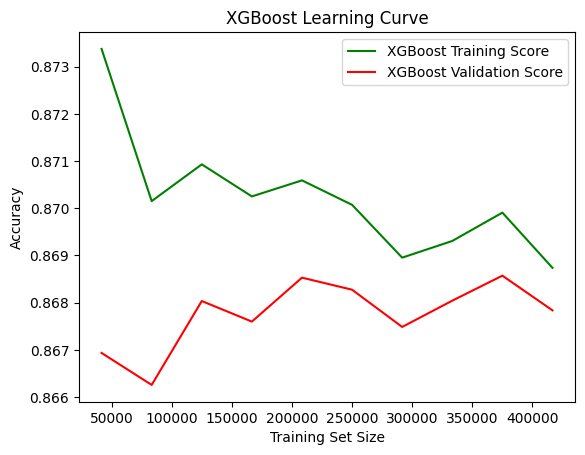

In [ ]:
# Learning curve for XGBoost
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model,
    Xtrain, ytrain,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="XGBoost Training Score", color="green")
plt.plot(train_sizes, test_mean, label="XGBoost Validation Score", color="red")
plt.title("XGBoost Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
#LGBM
lgb_model = lgb.LGBMClassifier(n_estimators=100,
                               learning_rate=0.1,
                               class_weight='balanced',
                               max_depth=10,
                               random_state=42,
                               verbose=-1)
lgb_model.fit(Xtrain, ytrain)
y_pred = lgb_model.predict(Xtest)
# Evaluate
print("Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_pred))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
print("Classification Report:\n", classification_report(ytest, y_pred, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))


Model Evaluation Metrics:

Accuracy: 0.78444244811462
Confusion Matrix:
 [[64239  1013 19961   352]
 [  179 18666   169   305]
 [ 3328  1494 13423   560]
 [   67   374   272  5837]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.95      0.75      0.84     85565
defacement(1)       0.87      0.97      0.91     19319
  phishing(2)       0.40      0.71      0.51     18805
   malware(3)       0.83      0.89      0.86      6550

     accuracy                           0.78    130239
    macro avg       0.76      0.83      0.78    130239
 weighted avg       0.85      0.78      0.80    130239



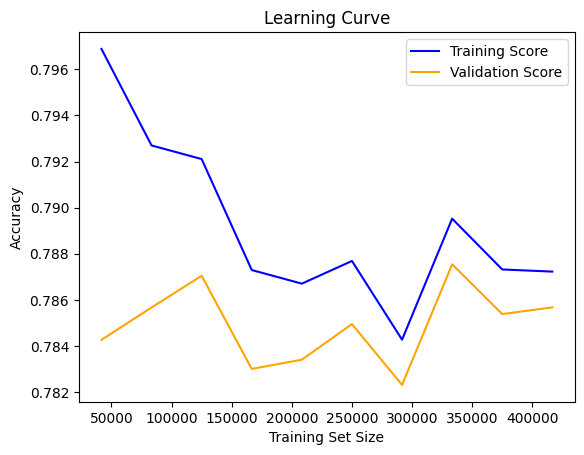

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
        lgb_model,
        Xtrain, ytrain,
        cv=5,
        scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score", color="blue")
plt.plot(train_sizes, test_mean, label="Validation Score", color="orange")
plt.title("Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
# xgb_model.save_model("xgboost_model.json")
lgb_model.booster_.save_model("lgbm_model_weightedclass.txt")

In [ ]:
#catboost
catmodel = CatBoostClassifier(
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42,
    auto_class_weights='Balanced'
)
catmodel.fit(Xtrain, ytrain,
          eval_set=(Xtest, ytest))
y_test_pred = catmodel.predict(Xtest)
print("Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(ytest, y_test_pred))
print("Classification Report:\n", classification_report(ytest, y_test_pred, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))

Model Evaluation Metrics:

Accuracy: 0.8263193052772211
Confusion Matrix:
 [[69638  1093 14433   401]
 [  168 18675   183   293]
 [ 3462  1373 13458   512]
 [   59   368   275  5848]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.95      0.81      0.88     85565
defacement(1)       0.87      0.97      0.91     19319
  phishing(2)       0.47      0.72      0.57     18805
   malware(3)       0.83      0.89      0.86      6550

     accuracy                           0.83    130239
    macro avg       0.78      0.85      0.81    130239
 weighted avg       0.86      0.83      0.84    130239



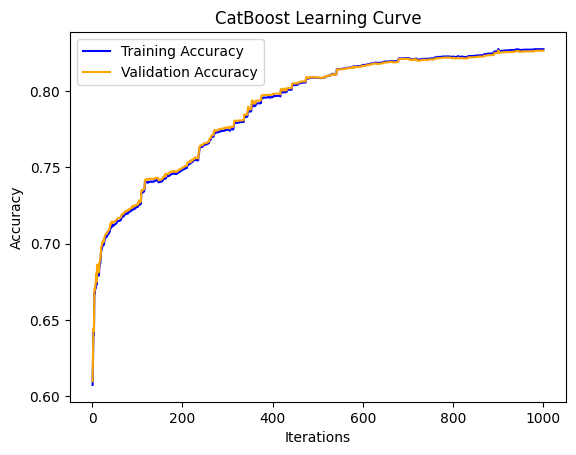

In [ ]:
eval_results = catmodel.eval_metrics(Pool(Xtest, ytest), metrics=['MultiClass'])

train_acc = []
val_acc = []

for i in range(catmodel.tree_count_):
    # predict on train and test using first i+1 trees
    ytrain_pred = catmodel.predict(Xtrain, ntree_end=i+1)
    ytest_pred = catmodel.predict(Xtest, ntree_end=i+1)

    train_acc.append(accuracy_score(ytrain, ytrain_pred))
    val_acc.append(accuracy_score(ytest, ytest_pred))

# Plot learning curve
plt.figure()
plt.plot(range(1, len(train_acc)+1), train_acc, label="Training Accuracy", color="blue")
plt.plot(range(1, len(val_acc)+1), val_acc, label="Validation Accuracy", color="orange")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.title("CatBoost Learning Curve")
plt.legend()
plt.show()

In [ ]:
catmodel.save_model('catboost_modelweighted.cbm')

In [ ]:
#Class wieghted loss(URLNet)
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)

Class weights: tensor([0.3803, 1.6878, 1.7298, 5.0061])


In [ ]:
#URLnet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleURLNet().to(device)

criterion = nn.CrossEntropyLoss(class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10

train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    correct = 0
    total = 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_accuracy = correct / total
    train_acc_history.append(train_accuracy)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in test_loader:   # <-- changed here
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

    val_accuracy = correct / total
    val_acc_history.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f}")

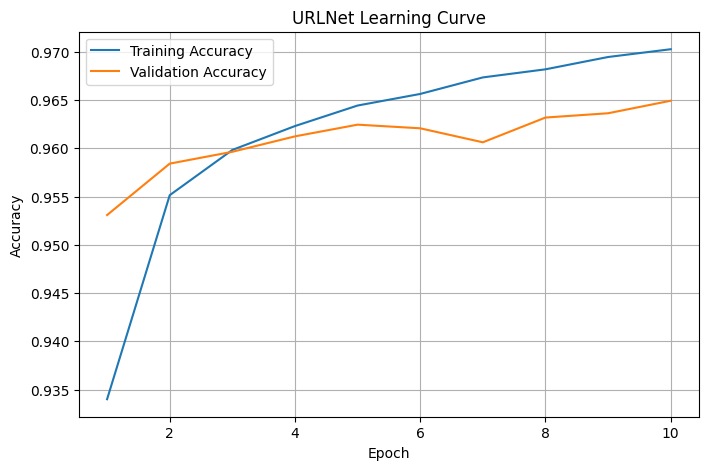

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc_history, label="Training Accuracy")
plt.plot(epochs, val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("URLNet Learning Curve")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y.numpy())
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]
))



Confusion Matrix:
[[83825    32  1749    15]
 [   18 19244    27     3]
 [ 2157   194 16371   100]
 [   31    30   212  6231]]

Classification Report:
               precision    recall  f1-score   support

    benign(0)       0.97      0.98      0.98     85621
defacement(1)       0.99      1.00      0.99     19292
  phishing(2)       0.89      0.87      0.88     18822
   malware(3)       0.98      0.96      0.97      6504

     accuracy                           0.96    130239
    macro avg       0.96      0.95      0.95    130239
 weighted avg       0.96      0.96      0.96    130239



In [ ]:
torch.save(model.state_dict(), "urlnetWL.pth")

In [ ]:
#BERT
data = pd.read_csv('malicious_phish.csv')

# Map labels
label_map = {'benign':0, 'defacement':1, 'phishing':2, 'malware':3}
data['Category'] = data['type'].map(label_map)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class URLDataset(Dataset):
    def __init__(self, urls, labels, tokenizer, max_len=64):  # shorter max_len
        self.urls = urls
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.urls)

    def __getitem__(self, idx):
        url = str(self.urls[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            url,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels": torch.tensor(label)  # must be "labels"
        }


FileNotFoundError: [Errno 2] No such file or directory: 'malicious_phish.csv'

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    data["url"], data["Category"], test_size=0.2, random_state=42
)

train_dataset = URLDataset(Xtrain.tolist(), ytrain.tolist(), tokenizer)
test_dataset  = URLDataset(Xtest.tolist(), ytest.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(test_dataset, batch_size=16)

class BertURLClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_token = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        x = self.drop(cls_token)
        return self.fc(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = BertURLClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

num_epochs = 3
train_acc_history = []
val_acc_history = []



In [ ]:
for epoch in range(num_epochs):
    model.train()
    total, correct = 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    total, correct = 0, 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_acc = correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


In [ ]:
print("Classification Report:")
print(classification_report(all_labels, all_preds))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))
plt.figure()
plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT URL Classification Learning Curve")
plt.legend()
plt.show()


In [ ]:
#Voting
import numpy as np
from scipy.stats import mode

def hard_voting(predictions):
    preds = np.vstack(predictions)
    voted_preds, _ = mode(preds, axis=0)
    return voted_preds.flatten()

In [ ]:
#load model
gbm_model = lgb.Booster(model_file="lgbm_model.txt")
xgb_model = xgb.XGBClassifier()
xgb_model.load_model("xgboost_model.json")
cat_model = CatBoostClassifier()
cat_model.load_model("catboost_model.cbm")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

urlnet_model = SimpleURLNet(
    vocab_size=len(char2idx) + 1,
    embed_dim=32,
    num_classes=4
)

urlnet_model.load_state_dict(
    torch.load("urlnet.pth", map_location=device)
)

urlnet_model.to(device)
urlnet_model.eval()

SimpleURLNet(
  (embedding): Embedding(101, 32, padding_idx=0)
  (conv1): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)

In [ ]:
pred_lgbm = gbm_model.predict(Xtest).argmax(axis=1)
pred_xgb  = xgb_model.predict(Xtest)
pred_cat = cat_model.predict(Xtest, prediction_type="Class")
pred_cat = pred_cat.flatten()
tree_voting_preds = hard_voting([
    pred_lgbm,
    pred_xgb,
    pred_cat
])


def predict_urlnet(model, dataloader, device):
    model.eval()
    preds = []

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            outputs = model(x)
            pred = torch.argmax(outputs, dim=1)
            preds.extend(pred.cpu().numpy())

    return np.array(preds)


In [ ]:
pred_urlnet = predict_urlnet(urlnet_model, test_loader, device)

In [ ]:
final_preds = hard_voting([
    pred_lgbm,
    pred_xgb,
    pred_cat,
    pred_urlnet
])
print("Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))

Accuracy: 0.5217945469483027
              precision    recall  f1-score   support

           0       0.66      0.74      0.70     85621
           1       0.15      0.16      0.16     19292
           2       0.16      0.07      0.10     18822
           3       0.05      0.04      0.05      6504

    accuracy                           0.52    130239
   macro avg       0.25      0.25      0.25    130239
weighted avg       0.48      0.52      0.50    130239



In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter
print("Before SMOTE:", Counter(ytrain))


Before SMOTE: Counter({0: 342538, 1: 77138, 2: 75306, 3: 25970})


In [ ]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42,
    k_neighbors=5
)

Xtrain_smote, ytrain_smote = smote.fit_resample(Xtrain, ytrain)
print("After SMOTE:", Counter(ytrain_smote))



After SMOTE: Counter({0: 342538, 2: 342538, 3: 342538, 1: 342538})


In [ ]:
#Xgboost smote
xgb_smote = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
)
xgb_smote.fit(Xtrain_smote, ytrain_smote)
pred_xgb_smote = xgb_smote.predict(Xtest)
# Evaluate XGBoost
print("XGBoost Model Evaluation Metrics:\n")
print("Accuracy:", accuracy_score(ytest, pred_xgb_smote))
print("Confusion Matrix:\n", confusion_matrix(ytest, pred_xgb_smote))
print("Classification Report:\n", classification_report(ytest, pred_xgb_smote, target_names=["benign(0)", "defacement(1)", "phishing(2)", "malware(3)"]))


XGBoost Model Evaluation Metrics:

Accuracy: 0.7596495673339015
Confusion Matrix:
 [[61753  1157 22151   504]
 [  190 18612   140   377]
 [ 3429  1784 12865   727]
 [   74   486   284  5706]]
Classification Report:
                precision    recall  f1-score   support

    benign(0)       0.94      0.72      0.82     85565
defacement(1)       0.84      0.96      0.90     19319
  phishing(2)       0.36      0.68      0.47     18805
   malware(3)       0.78      0.87      0.82      6550

     accuracy                           0.76    130239
    macro avg       0.73      0.81      0.75    130239
 weighted avg       0.84      0.76      0.78    130239



In [ ]:
xgb_smote.save_model("xgboostsmote_model.json")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


NameError: name 'test_sizes' is not defined

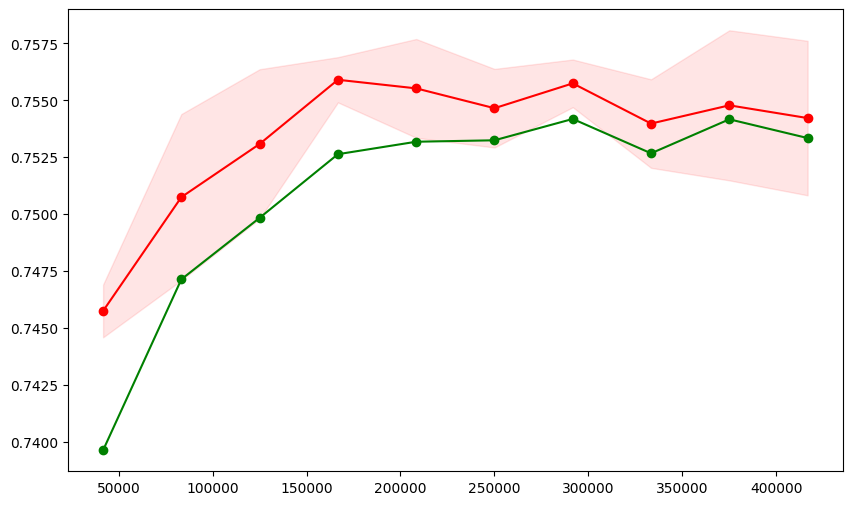

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# 1. Define the Pipeline
# We combine SMOTE and XGBoost so SMOTE happens *inside* the CV loop
model_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6
    ))
])

# 2. Compute the Learning Curve
# Note: Use your ORIGINAL Xtrain/ytrain here, not the already smoted ones
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    model_pipeline,
    Xtrain, ytrain,  # Use original data before global SMOTE
    cv=cv,
    scoring='accuracy', # Or 'f1_macro' etc.
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# 3. Calculate Mean and Std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

# Fill the area between the standard deviation
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(test_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning Curve (XGBoost + SMOTE)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()